In [1]:
import pandas as pd

channel_costs = pd.read_csv('../01-data/processed/channel_costs.csv')

print(channel_costs.shape)
print(channel_costs.columns)
channel_costs.head()

(36, 6)
Index(['channel', 'month', 'year', 'spend_inr', 'impressions', 'clicks'], dtype='object')


,channel,month,year,spend_inr,impressions,clicks
0,Organic Search,Oct,2019,850000,2400000,48000
1,Paid Search,Oct,2019,2200000,1800000,54000
2,Email,Oct,2019,120000,680000,61200
3,Social Media,Oct,2019,1650000,3200000,76800
4,Referral,Oct,2019,280000,420000,29400


In [2]:
users = pd.read_csv(
    '../01-data/processed/cleaned_users.csv',
    low_memory=False
)

print(users['traffic_source'].value_counts())

traffic_source
Search      70075
Organic     15110
Facebook     5816
Email        4947
Display      4052
Name: count, dtype: int64


In [3]:
order_items = pd.read_csv(
    '../01-data/processed/cleaned_order_items.csv'
)

print(order_items.columns)

Index(['id', 'order_id', 'user_id', 'product_id', 'inventory_item_id',
       'status', 'created_at', 'shipped_at', 'delivered_at', 'returned_at',
       'sale_price', 'sale_price_capped', 'product_master_id', 'cost',
       'gross_margin'],
      dtype='object')


In [4]:
orders = pd.read_csv(
    '../01-data/processed/cleaned_orders.csv'
)

order_items = pd.read_csv(
    '../01-data/processed/cleaned_order_items.csv'
)

revenue_df = (
    order_items
    .groupby('user_id')['sale_price']
    .sum()
    .reset_index()
)

revenue_df.head()

,user_id,sale_price
0,1,159.990000
1,2,22.000000
2,3,402.200001
3,4,148.000000
4,5,65.650000


In [5]:
users = pd.read_csv(
    '../01-data/processed/cleaned_users.csv',
    low_memory=False
)

order_items = pd.read_csv(
    '../01-data/processed/cleaned_order_items.csv'
)

user_revenue = (
    order_items
    .groupby('user_id')['sale_price']
    .sum()
    .reset_index()
)

channel_ltv = (

    users[
        ['id','traffic_source']
    ]

    .merge(
        user_revenue,
        left_on='id',
        right_on='user_id',
        how='left'
    )

)

channel_ltv['sale_price'] = (
    channel_ltv['sale_price']
    .fillna(0)
)

channel_ltv.head()

,id,traffic_source,user_id,sale_price
0,457,Search,457.0,99.989998
1,6578,Search,NaN,0.000000
2,36280,Email,36280.0,102.090000
3,60193,Search,60193.0,24.000000
4,64231,Search,64231.0,89.930000


In [6]:
ltv_by_channel = (

    channel_ltv
    .groupby('traffic_source')
    .agg(

        users=('id','count'),

        avg_ltv=('sale_price','mean')

    )

    .reset_index()

)

ltv_by_channel

,traffic_source,users,avg_ltv
0,Display,4052,107.743065
1,Email,4947,106.823487
2,Facebook,5816,107.870686
3,Organic,15110,108.369935
4,Search,70075,108.415877


In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

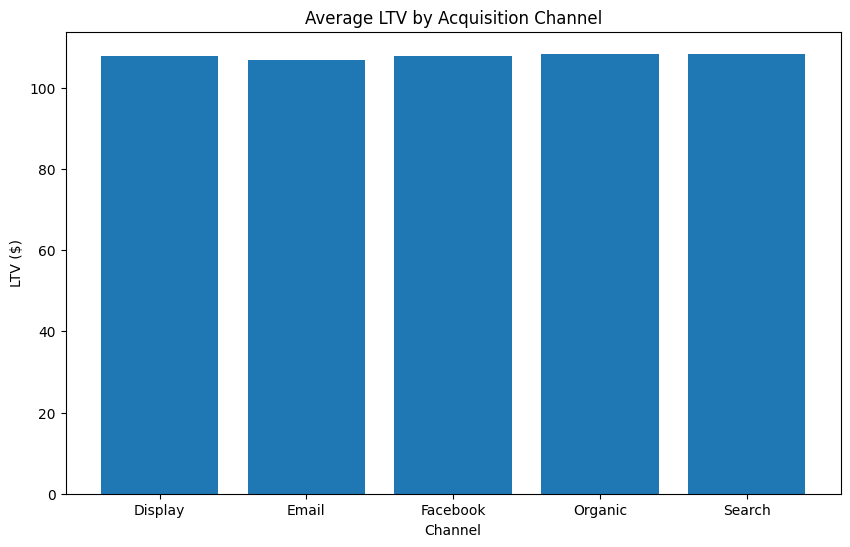

In [9]:
plt.figure(figsize=(10,6))

plt.bar(
    ltv_by_channel['traffic_source'],
    ltv_by_channel['avg_ltv']
)

plt.title(
    'Average LTV by Acquisition Channel'
)

plt.ylabel('LTV ($)')
plt.xlabel('Channel')

plt.show()

In [10]:
channel_costs = pd.read_csv(
    '../01-data/processed/channel_costs.csv'
)

channel_spend = (

    channel_costs
    .groupby('channel')['spend_inr']
    .sum()
    .reset_index()

)

channel_spend

,channel,spend_inr
0,Direct,0
1,Email,795000
2,Organic Search,5370000
3,Paid Search,13950000
4,Referral,1830000
5,Social Media,10400000


In [11]:
channel_map = {

    'Search':'Paid Search',

    'Organic':'Organic Search',

    'Facebook':'Social Media',

    'Email':'Email',

    'Display':'Display'

}

ltv_by_channel['mapped_channel'] = (
    ltv_by_channel['traffic_source']
    .map(channel_map)
)

In [12]:
cac_df = (

    ltv_by_channel

    .merge(
        channel_spend,
        left_on='mapped_channel',
        right_on='channel',
        how='left'
    )

)

cac_df['cac'] = (
    cac_df['spend_inr']
    /
    cac_df['users']
)

cac_df[
    [
        'traffic_source',
        'users',
        'avg_ltv',
        'cac'
    ]
]

,traffic_source,users,avg_ltv,cac
0,Display,4052,107.743065,NaN
1,Email,4947,106.823487,160.703457
2,Facebook,5816,107.870686,1788.170564
3,Organic,15110,108.369935,355.393779
4,Search,70075,108.415877,199.072422


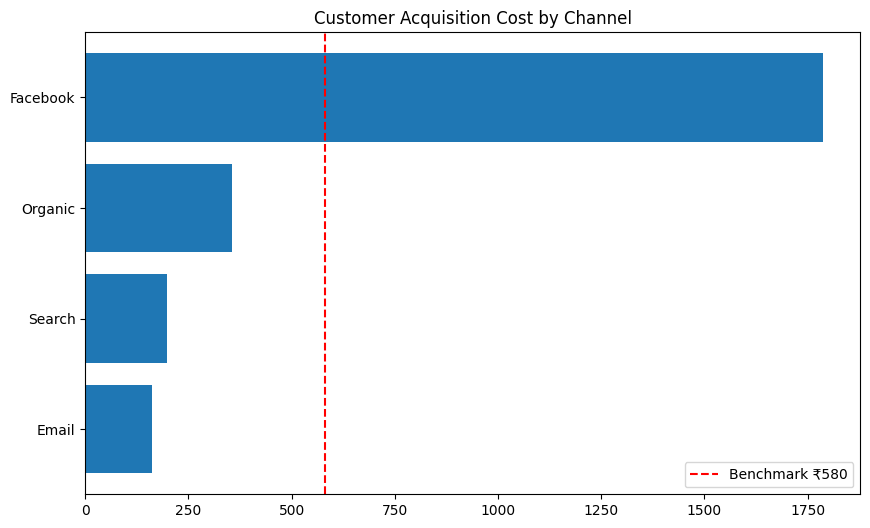

In [13]:
cac_df = cac_df.sort_values(
    'cac'
)

plt.figure(figsize=(10,6))

plt.barh(
    cac_df['traffic_source'],
    cac_df['cac']
)

plt.axvline(
    580,
    color='red',
    linestyle='--',
    label='Benchmark ₹580'
)

plt.legend()

plt.title(
    'Customer Acquisition Cost by Channel'
)

plt.show()

In [14]:
cac_df['ltv_cac_ratio'] = (
    cac_df['avg_ltv']
    /
    cac_df['cac']
)

cac_df[
    [
        'traffic_source',
        'avg_ltv',
        'cac',
        'ltv_cac_ratio'
    ]
]

,traffic_source,avg_ltv,cac,ltv_cac_ratio
1,Email,106.823487,160.703457,0.664724
4,Search,108.415877,199.072422,0.544605
3,Organic,108.369935,355.393779,0.304929
2,Facebook,107.870686,1788.170564,0.060325
0,Display,107.743065,NaN,NaN


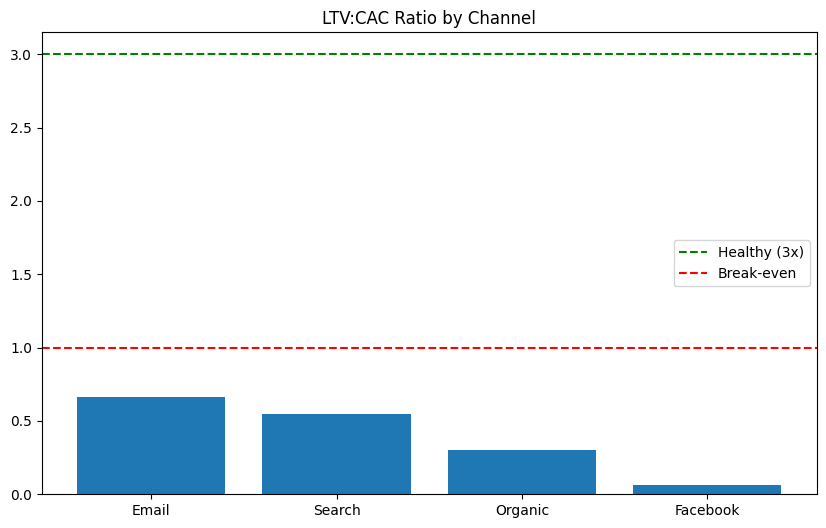

In [15]:
plt.figure(figsize=(10,6))

plt.bar(
    cac_df['traffic_source'],
    cac_df['ltv_cac_ratio']
)

plt.axhline(
    3,
    color='green',
    linestyle='--',
    label='Healthy (3x)'
)

plt.axhline(
    1,
    color='red',
    linestyle='--',
    label='Break-even'
)

plt.legend()

plt.title(
    'LTV:CAC Ratio by Channel'
)

plt.show()

In [16]:
cac_df['monthly_revenue_per_user'] = (
    cac_df['avg_ltv'] / 12
)

cac_df['payback_months'] = (
    cac_df['cac']
    /
    cac_df['monthly_revenue_per_user']
)

cac_df[
[
'traffic_source',
'cac',
'avg_ltv',
'payback_months'
]
]

,traffic_source,cac,avg_ltv,payback_months
1,Email,160.703457,106.823487,18.052598
4,Search,199.072422,108.415877,22.034310
3,Organic,355.393779,108.369935,39.353399
2,Facebook,1788.170564,107.870686,198.923800
0,Display,NaN,107.743065,NaN


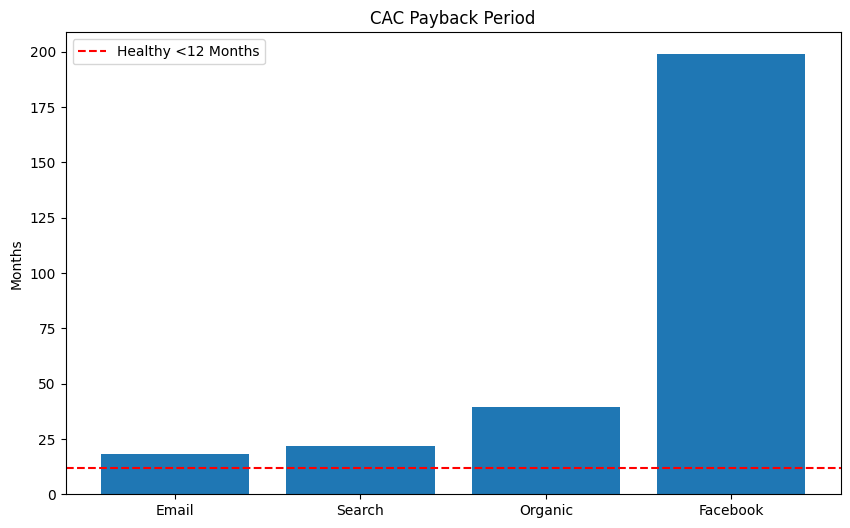

In [17]:
plt.figure(figsize=(10,6))

plt.bar(
    cac_df['traffic_source'],
    cac_df['payback_months']
)

plt.axhline(
    12,
    color='red',
    linestyle='--',
    label='Healthy <12 Months'
)

plt.legend()

plt.title(
    'CAC Payback Period'
)

plt.ylabel('Months')

plt.show()

In [18]:
orders = pd.read_csv(
    '../01-data/processed/cleaned_orders.csv'
)

order_items = pd.read_csv(
    '../01-data/processed/cleaned_order_items.csv'
)

orders['created_at'] = pd.to_datetime(
    orders['created_at'],
    format='mixed',
    utc=True
)

order_items['created_at'] = pd.to_datetime(
    order_items['created_at'],
    format='mixed',
    utc=True
)

order_items['order_month'] = (
    order_items['created_at']
    .dt.to_period('M')
)

monthly_revenue = (
    order_items
    .groupby('order_month')['sale_price']
    .sum()
    .reset_index()
)

monthly_revenue.tail(12)

C:\Users\OM\AppData\Local\Temp\ipykernel_11496\537378160.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period('M')


,order_month,sale_price
49,2023-02,271505.070164
50,2023-03,326302.760271
51,2023-04,316383.500436
52,2023-05,343971.120315
53,2023-06,363314.140351
54,2023-07,417457.930678
55,2023-08,447580.900399
56,2023-09,481772.300609
57,2023-10,544430.900469
58,2023-11,582231.620540


In [19]:
monthly_revenue['month_num'] = range(
    len(monthly_revenue)
)

monthly_revenue.tail()

,order_month,sale_price,month_num
56,2023-09,481772.300609,56
57,2023-10,544430.900469,57
58,2023-11,582231.620540,58
59,2023-12,720588.810540,59
60,2024-01,824556.800977,60


In [20]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = monthly_revenue[['month_num']]
y = monthly_revenue['sale_price']

model = LinearRegression()

model.fit(X,y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 8787.616759289864
Intercept: -86134.75012705344


In [21]:
future_months = pd.DataFrame({

    'month_num': range(
        len(monthly_revenue),
        len(monthly_revenue)+6
    )

})

future_months['base_forecast'] = (
    model.predict(future_months)
)

future_months

,month_num,base_forecast
0,61,449909.872190
1,62,458697.488949
2,63,467485.105708
3,64,476272.722467
4,65,485060.339227
5,66,493847.955986


In [22]:
future_months['pessimistic'] = (
    future_months['base_forecast']
    * 0.90
)

future_months['optimistic'] = (
    future_months['base_forecast']
    * 1.15
)

future_months

,month_num,base_forecast,pessimistic,optimistic
0,61,449909.872190,404918.884971,517396.353018
1,62,458697.488949,412827.740054,527502.112291
2,63,467485.105708,420736.595137,537607.871564
3,64,476272.722467,428645.450221,547713.630838
4,65,485060.339227,436554.305304,557819.390111
5,66,493847.955986,444463.160387,567925.149384


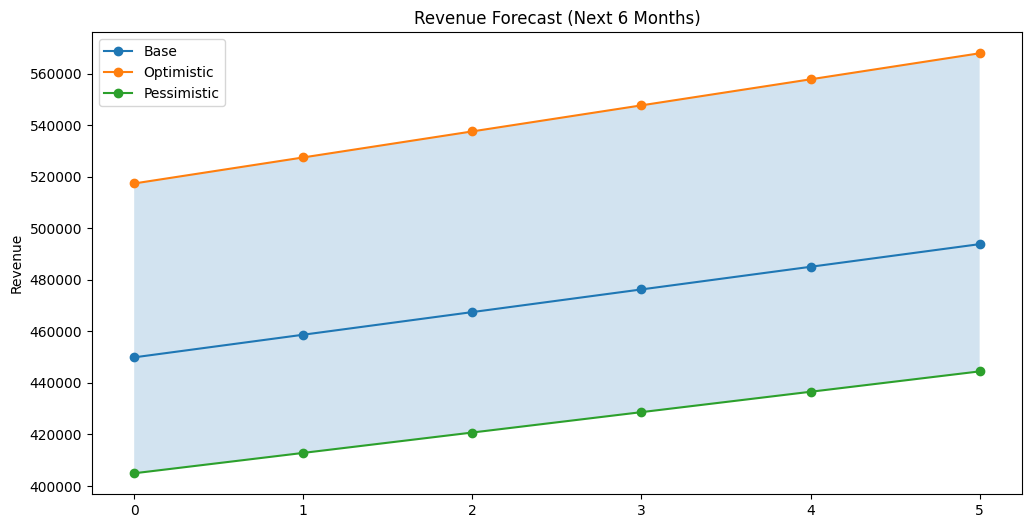

In [23]:
plt.figure(figsize=(12,6))

plt.plot(
    future_months['base_forecast'],
    marker='o',
    label='Base'
)

plt.plot(
    future_months['optimistic'],
    marker='o',
    label='Optimistic'
)

plt.plot(
    future_months['pessimistic'],
    marker='o',
    label='Pessimistic'
)

plt.fill_between(
    future_months.index,
    future_months['pessimistic'],
    future_months['optimistic'],
    alpha=0.2
)

plt.title(
    'Revenue Forecast (Next 6 Months)'
)

plt.ylabel('Revenue')

plt.legend()

plt.show()

In [25]:
user_revenue = (

    order_items
    .groupby('user_id')['sale_price']
    .sum()
    .reset_index()

)

user_revenue.columns = [
    'user_id',
    'total_revenue'
]

In [26]:
last_purchase = (

    orders.groupby('user_id')
    ['created_at']
    .max()
    .reset_index()

)

last_purchase.columns = [
    'user_id',
    'last_purchase'
]

analysis_date = orders['created_at'].max()

last_purchase['days_since_purchase'] = (

    analysis_date
    -
    last_purchase['last_purchase']

).dt.days

last_purchase.head()

,user_id,last_purchase,days_since_purchase
0,1,2022-07-18 12:55:00+00:00,548
1,2,2022-02-20 10:34:00+00:00,696
2,3,2023-08-08 09:13:00+00:00,162
3,4,2022-10-18 09:31:00+00:00,456
4,5,2022-10-20 10:03:00+00:00,454


In [27]:
last_purchase['risk_group'] = np.where(

    last_purchase['days_since_purchase'] > 90,

    'Churned',

    np.where(

        last_purchase['days_since_purchase'] > 45,

        'At Risk',

        'Active'

    )

)

last_purchase['risk_group'].value_counts()

risk_group
Churned    58824
Active     13472
At Risk     7748
Name: count, dtype: int64

In [28]:
risk_revenue = (

    last_purchase

    .merge(
        user_revenue,
        on='user_id',
        how='left'
    )

    .groupby('risk_group')
    ['total_revenue']

    .sum()

    .reset_index()

)

risk_revenue

,risk_group,total_revenue
0,Active,2.141135e+06
1,At Risk,1.178269e+06
2,Churned,7.507714e+06


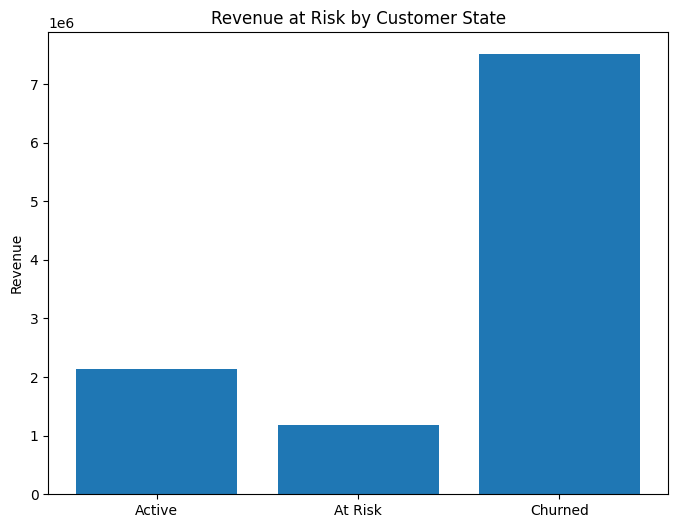

In [29]:
plt.figure(figsize=(8,6))

plt.bar(
    risk_revenue['risk_group'],
    risk_revenue['total_revenue']
)

plt.title(
    'Revenue at Risk by Customer State'
)

plt.ylabel('Revenue')

plt.show()

In [30]:
baseline_cvr = 0.12

monthly_visitors = 380000

aov = 2400

scenarios = [

    0.005,
    0.01,
    0.015,
    0.02

]

results = []

for delta in scenarios:

    extra_conversions = (
        monthly_visitors
        * delta
    )

    extra_revenue = (
        extra_conversions
        * aov
    )

    results.append(

        [

            f"+{delta*100:.1f}%",

            round(extra_revenue)

        ]

    )

sensitivity = pd.DataFrame(

    results,

    columns=[
        'CVR Improvement',
        'Monthly Revenue Increase'
    ]

)

sensitivity

,CVR Improvement,Monthly Revenue Increase
0,+0.5%,4560000
1,+1.0%,9120000
2,+1.5%,13680000
3,+2.0%,18240000


In [2]:
import pandas as pd

users = pd.read_csv('../01-data/processed/cleaned_users.csv')
channel_costs = pd.read_csv('../01-data/processed/channel_costs.csv')
order_items = pd.read_csv('../01-data/processed/cleaned_order_items.csv')

C:\Users\OM\AppData\Local\Temp\ipykernel_13724\2069878918.py:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  users = pd.read_csv('../01-data/processed/cleaned_users.csv')


In [3]:
ltv_data = users.merge(
    order_items.groupby('user_id')['sale_price'].sum().reset_index(),
    left_on='id',
    right_on='user_id',
    how='left'
)

ltv_data['sale_price'] = ltv_data['sale_price'].fillna(0)

ltv_by_channel = (
    ltv_data
    .groupby('traffic_source')
    .agg(
        users=('id','count'),
        avg_ltv=('sale_price','mean')
    )
    .reset_index()
)

ltv_by_channel

,traffic_source,users,avg_ltv
0,Display,4052,107.743065
1,Email,4947,106.823487
2,Facebook,5816,107.870686
3,Organic,15110,108.369935
4,Search,70075,108.415877


In [4]:
channel_spend = (
    channel_costs
    .groupby('channel')['spend_inr']
    .sum()
    .reset_index()
)

channel_mapping = {
    'Search':'Paid Search',
    'Organic':'Organic Search',
    'Facebook':'Social Media',
    'Email':'Email'
}

ltv_by_channel['channel'] = (
    ltv_by_channel['traffic_source']
    .map(channel_mapping)
)

cac_df = ltv_by_channel.merge(
    channel_spend,
    on='channel',
    how='left'
)

cac_df['cac'] = (
    cac_df['spend_inr']
    /
    cac_df['users']
)

cac_df['ltv_cac_ratio'] = (
    cac_df['avg_ltv']
    /
    cac_df['cac']
)

cac_df[
[
'traffic_source',
'users',
'avg_ltv',
'cac',
'ltv_cac_ratio'
]
]

,traffic_source,users,avg_ltv,cac,ltv_cac_ratio
0,Display,4052,107.743065,NaN,NaN
1,Email,4947,106.823487,160.703457,0.664724
2,Facebook,5816,107.870686,1788.170564,0.060325
3,Organic,15110,108.369935,355.393779,0.304929
4,Search,70075,108.415877,199.072422,0.544605


In [5]:
cac_df.to_csv(
    '../outputs/channel_ltv_cac.csv',
    index=False
)

print("✅ channel_ltv_cac.csv created")

✅ channel_ltv_cac.csv created


In [7]:
import pandas as pd

forecast_df = pd.DataFrame({

    'month_num':[61,62,63,64,65,66],

    'base_forecast':[
        449909.872190,
        458697.488949,
        467485.105708,
        476272.722467,
        485060.339227,
        493847.955986
    ],

    'pessimistic':[
        404918.884971,
        412827.740054,
        420736.595137,
        428645.450221,
        436554.305304,
        444463.160387
    ],

    'optimistic':[
        517396.353018,
        527502.112291,
        537607.871564,
        547713.630838,
        557819.390111,
        567925.149384
    ]

})

forecast_df.head()

,month_num,base_forecast,pessimistic,optimistic
0,61,449909.872190,404918.884971,517396.353018
1,62,458697.488949,412827.740054,527502.112291
2,63,467485.105708,420736.595137,537607.871564
3,64,476272.722467,428645.450221,547713.630838
4,65,485060.339227,436554.305304,557819.390111


In [8]:
forecast_df.to_csv(
    '../outputs/revenue_forecast_3scenarios.csv',
    index=False
)

print("✅ revenue_forecast_3scenarios.csv created")

✅ revenue_forecast_3scenarios.csv created
